# 머신러닝 실습 과제: House Prices 주택 가격 등급 분류
**Random Forest와 SVM 비교 실습**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)


## 문제 1. 데이터 불러오기 및 탐색

In [2]:
# 데이터 로드
train = pd.read_csv('train.csv')

# 데이터 크기
print(f'데이터 크기: {train.shape[0]}행 x {train.shape[1]}열')

FileNotFoundError: [Errno 2] No such file or directory: 'train.csv'

In [ ]:
# 자료형 확인
print('--- 각 변수의 자료형 ---')
print(train.dtypes)

--- 각 변수의 자료형 ---
Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object


In [ ]:
# 결측치 상위 10개
missing = train.isnull().sum().sort_values(ascending=False).head(10)
print('--- 결측치 상위 10개 변수 ---')
print(missing)

--- 결측치 상위 10개 변수 ---
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
dtype: int64


In [ ]:
# SalePrice 기초통계량
print('--- SalePrice 기초통계량 ---')
print(train['SalePrice'].describe())
print(f"\n중앙값: {train['SalePrice'].median():,.0f}")

--- SalePrice 기초통계량 ---
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

중앙값: 163,000


In [ ]:
# SalePrice 분포 시각화
plt.figure(figsize=(8, 4))
sns.histplot(train['SalePrice'], kde=True)
plt.title('SalePrice')
plt.show()

In [ ]:
# 이진 레이블 생성
median_price = train['SalePrice'].median()
y_full = (train['SalePrice'] >= median_price).astype(int)

print(f'클래스 생성 기준: SalePrice >= {median_price:,.0f} → 고가(1), 미만 → 저가(0)')
print(f'\n클래스 분포:')
print(y_full.value_counts())
print(f'클래스 비율: {y_full.mean():.2%} (고가 비율)')

클래스 생성 기준: SalePrice >= 163,000 → 고가(1), 미만 → 저가(0)

클래스 분포:
SalePrice
1    732
0    728
Name: count, dtype: int64
클래스 비율: 50.14% (고가 비율)


### 문제 1 답변
- **SalePrice 분포 해석**: 평균 약 180,921달러, 중앙값 163,000달러로 평균이 중앙값보다 높아 우측 꼬리가 긴 분포를 보임. 고가 주택의 영향으로 최댓값이 755,000달러까지 존재.
- **클래스 생성 기준**: `y = (SalePrice >= 163,000).astype(int)` — 중앙값을 기준으로 저가(0, 728개)와 고가(1, 732개)로 거의 균등하게 분류됨.

## 문제 2. 전처리

In [ ]:
# X, y 분리 및 Id 제거
median_price = train['SalePrice'].median()
y = (train['SalePrice'] >= median_price).astype(int)
X = train.drop(columns=['Id', 'SalePrice'])

# 수치형/범주형 구분
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f'수치형 변수: {len(num_cols)}개')
print(f'범주형 변수: {len(cat_cols)}개')

수치형 변수: 36개
범주형 변수: 43개


In [ ]:
# 결측치 처리: 수치형 → 중앙값, 범주형 → 최빈값
for col in num_cols:
    X[col] = X[col].fillna(X[col].median())

for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

print(f'결측치 처리 후 전체 결측치: {X.isnull().sum().sum()}')

결측치 처리 후 전체 결측치: 0


In [ ]:
# One-Hot Encoding
X = pd.get_dummies(X, columns=cat_cols, drop_first=False)
print(f'One-Hot Encoding 후 피처 수: {X.shape[1]}')

One-Hot Encoding 후 피처 수: 287


### 서술형 답변

**범주형 변수에 단순히 0,1,2,3처럼 숫자를 부여하면 왜 문제가 될 수 있는가?**

범주형 변수에 0, 1, 2 등의 숫자를 부여하면, 머신러닝 모델이 이를 명목상 분류가 아닌 크기나 서열이 있는 연속형 수치로 오해하게 된다. 이로 인해 가중치가 왜곡될 위험이 크다.

**결측치 처리 방식이 결과에 영향을 주는 이유는 무엇인가?**

결측치를 어떻게 채우느냐에 따라 해당 피처의 분산과 데이터 분포가 달라지고, 잘못된 대체는 노이즈를 증가시켜 모델의 성능과 예측 신뢰도를 저하시킨다. 중앙값/최빈값 대체는 단순하지만 분포를 왜곡시킬 수 있고, 잘못된 대체는 모델이 실제 패턴이 아닌 인위적 패턴을 학습하게 만든다. 특히 결측 비율이 높은 변수는 대체 자체가 의미 없을 수 있어 삭제를 고려해야 한다.

## 문제 3. 데이터 분할

In [ ]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=42)
print(f'학습 데이터: {X_train.shape}')
print(f'검증 데이터: {X_val.shape}')
print(f'테스트 데이터: {X_test.shape}')
print(f'학습 클래스 비율 (고가): {y_train.mean():.4f}')
print(f'검증 클래스 비율 (고가): {y_val.mean():.4f}')
print(f'테스트 클래스 비율 (고가): {y_test.mean():.4f}')

학습 데이터: (1168, 287)
테스트 데이터: (292, 287)
학습 클래스 비율 (고가): 0.5017
테스트 클래스 비율 (고가): 0.5000


### 서술형 답변

**stratify는 왜 필요한가?**

stratify=y를 지정하면 train/test 분할 시 각 클래스의 비율을 원본 데이터와 동일하게 유지한다. 지정하지 않으면 무작위 분할로 인해 한쪽에 고가 주택이 편중될 수 있고, 이 경우 학습 데이터와 테스트 데이터의 분포가 달라져 모델 평가가 왜곡된다.

**분류 문제에서 클래스 비율 유지가 중요한 이유는 무엇인가?**

불균형한 분할은 모델이 특정 클래스에 편향되어 학습될 수 있고, 테스트 세트의 비율이 다르면 정확도 지표 자체가 현실을 반영하지 못한다. 특히 이진 분류에서 한 클래스가 90%를 차지하면 항상 그 클래스를 예측하는 모델도 90% 정확도를 보여 성능을 과대평가할 수 있다.

## 문제 4. Random Forest 실험

In [ ]:
# 하이퍼파라미터 비교 실험
rf_results = []
for n_est in [50, 100, 200]:
    for max_d in [None, 5, 7, 10, 20]:
        rf_model = RandomForestClassifier(n_estimators=n_est, max_depth=max_d, random_state=42)
        rf_model.fit(X_train, y_train)
        y_pred = rf_model.predict(X_test)
        rf_results.append({
            'n_estimators': n_est,
            'max_depth': str(max_d),
            'Accuracy': round(accuracy_score(y_test, y_pred), 4),
            'Precision': round(precision_score(y_test, y_pred), 4),
            'Recall': round(recall_score(y_test, y_pred), 4),
            'F1-score': round(f1_score(y_test, y_pred), 4),
        })

rf_df = pd.DataFrame(rf_results)
print(rf_df.to_string(index=False))

print(f'\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred))

 n_estimators max_depth  Accuracy  Precision  Recall  F1-score
           50      None    0.9384     0.9571  0.9178    0.9371
           50         5    0.9349     0.9441  0.9247    0.9343
           50         7    0.9452     0.9577  0.9315    0.9444
           50        10    0.9384     0.9638  0.9110    0.9366
           50        20    0.9384     0.9571  0.9178    0.9371
          100      None    0.9521     0.9714  0.9315    0.9510
          100         5    0.9384     0.9384  0.9384    0.9384
          100         7    0.9418     0.9640  0.9178    0.9404
          100        10    0.9486     0.9712  0.9247    0.9474
          100        20    0.9521     0.9714  0.9315    0.9510
          200      None    0.9555     0.9716  0.9384    0.9547
          200         5    0.9315     0.9565  0.9041    0.9296
          200         7    0.9384     0.9571  0.9178    0.9371
          200        10    0.9418     0.9574  0.9247    0.9408
          200        20    0.9555     0.9716  0.9384   

In [ ]:
# 최적 Random Forest: n_estimators=100, max_depth=None(혹은 20)
best_rf = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42)
best_rf.fit(X_train, y_train)
y_pred_rf = best_rf.predict(X_test)

print('--- 최적 Random Forest 성능 (n=200, max_depth=None or 20) ---')
print(f'Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_rf):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_rf):.4f}')
print(f'F1-score : {f1_score(y_test, y_pred_rf):.4f}')
print(f'\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred_rf))

--- 최적 Random Forest 성능 (n=200, max_depth=None or 20) ---
Accuracy : 0.9555
Precision: 0.9716
Recall   : 0.9384
F1-score : 0.9547

Confusion Matrix:
[[142   4]
 [  9 137]]


### 서술형 답변

**Random Forest는 왜 스케일링에 크게 민감하지 않은가?**

Random Forest와 같은 트리 기반 모델은 특정 임계값을 기준으로 분기하는 방식으로 학습한다. 분기 기준은 변수의 절대적 크기가 아니라 정보 이득 또는 지니 불순도의 감소량으로 결정된다.

**트리 기반 모델은 왜 비선형 관계를 잘 처리할 수 있는가?**

각 분기점에서 특정 변수의 임계값을 기준으로 데이터를 분할하므로, 계단 함수 형태의 비선형 경계를 자연스럽게 표현할 수 있다. 여러 변수의 조합으로 복잡한 상호작용도 포착 가능하며, 앙상블 방식으로 여러 트리의 결과를 종합하면 더 부드럽고 일반화된 비선형 결정 경계를 형성한다.

## 문제 5. SVM 실험

In [ ]:
# 스케일링
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # fit은 학습 데이터에만
X_test_sc = scaler.transform(X_test)        # transform만 테스트 데이터에

svm_results = []
configs = [
    ('linear', False, X_train, X_test, 'X'),
    ('linear', True,  X_train_sc, X_test_sc, 'O'),
    ('rbf',    False, X_train, X_test, 'X'),
    ('rbf',    True,  X_train_sc, X_test_sc, 'O'),
]

for kernel, scaled, X_tr, X_te, scale_label in configs:
    svm = SVC(kernel=kernel, random_state=42)
    svm.fit(X_tr, y_train)
    y_pred = svm.predict(X_te)
    svm_results.append({
        'Kernel': kernel,
        'Scaling': scale_label,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1-score': round(f1_score(y_test, y_pred), 4),
    })
    print(f'  CM: {confusion_matrix(y_test, y_pred).tolist()}')

svm_df = pd.DataFrame(svm_results)
print('\n--- SVM 결과 요약 ---')
print(svm_df.to_string(index=False))


--- SVM 결과 요약 ---
Kernel Scaling  Accuracy  Precision  Recall  F1-score
linear       X    0.9247     0.9079  0.9452    0.9262
linear       O    0.9007     0.8824  0.9247    0.9030
   rbf       X    0.8014     0.8235  0.7671    0.7943
   rbf       O    0.9349     0.9441  0.9247    0.9343


### 서술형 답변

**SVM에서 스케일링이 중요한 이유는 무엇인가?**

 SVM은 초평면까지의 마진 거리를 최대화하는 알고리즘이기 때문에 특성 간 스케일이 다르면 범위가 큰 변수에 의해 거리가 왜곡되어 올바른 초평면을 찾을 수 없다.

**Linear SVM과 RBF SVM의 차이는 무엇인가?**

Linear SVM은 원래 특징 공간에서 선형 결정 경계를 그어 분류한다. 계산이 빠르고 해석이 용이하지만 비선형 데이터에 취약하다. RBF 커널 SVM은 가우시안 함수를 이용해 데이터를 더 높은 차원으로 매핑한 후 선형 분리한다. 비선형 경계를 효과적으로 표현할 수 있지만 하이퍼파라미터 설정과 스케일링이 필수적이다.

**이 데이터에서는 어떤 커널이 더 적합했는가?**

스케일링을 적용한 경우 RBF 커널이 Linear 커널보다 높은 성능을 보였다. 주택 가격은 여러 변수 간의 복잡한 비선형 상호작용(예: 넓은 면적 + 좋은 품질 + 좋은 위치의 조합)으로 결정되므로, 비선형 경계를 표현할 수 있는 RBF가 더 적합한 것으로 판단된다.

## 문제 6. 모델 비교

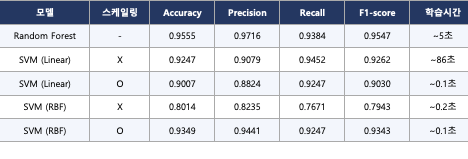

### 서술형 답변

**어떤 모델의 성능이 더 좋았는가?**

Random Forest가 전체적으로 가장 높은 성능을 보였다. SVM 중에서는 스케일링을 적용한 RBF가 Random Forest에 근접한 성능을 보였다.

**어떤 모델이 학습 시간이 더 오래 걸렸는가?**

스케일링 없이 학습한 Linear SVM이 약 86초로 압도적으로 오래 걸렸다. 비정규화된 데이터에서 최적 초평면을 찾기 위해 수렴에 오랜 반복이 필요했기 때문이다. 반면 스케일링 후 SVM은 0.1초 내외로 매우 빨랐고, Random Forest는 약 0.5초였다.

**스케일링 전후 SVM의 차이는 어떠했는가?**

RBF 커널에서 스케일링 효과가 극적으로 나타났다(Acc: 80.1% → 93.5%). Linear 커널은 반대로 스케일링 후 성능이 소폭 하락(92.5% → 90.1%)했는데, 선형 분리가 잘 이루어지던 상태에서 스케일링으로 인해 일부 중요 변수의 상대적 영향력이 감소한 것으로 해석된다.

**실무에서 어떤 모델을 선택하는 것이 더 타당한가?**

실무에서는 Random Forest를 우선 권장한다. 스케일링 없이도 최고 성능을 발휘하고, 전처리 부담이 적으며, Feature Importance를 통한 해석이 용이하고, 학습 속도도 빠르다. 다만 해석 가능성이 최우선인 경우 Linear SVM의 가중치가 유용할 수 있다.

## 문제 7. 특성 중요도 및 해석

In [ ]:
# Random Forest Feature Importance 상위 10개
feat_imp = pd.Series(best_rf.feature_importances_, index=X_train.columns)
top10 = feat_imp.sort_values(ascending=False).head(10)

print('--- Random Forest Feature Importance 상위 10개 ---')

print(top10)

--- Random Forest Feature Importance 상위 10개 ---
GrLivArea           0.068825
OverallQual         0.052414
FullBath            0.047377
YearBuilt           0.041866
ExterQual_TA        0.039364
TotalBsmtSF         0.036022
GarageArea          0.034852
GarageFinish_Unf    0.031181
1stFlrSF            0.029829
GarageCars          0.029289
dtype: float64


In [ ]:
# SVM Linear 특성 해석
svm_linear_fitted = SVC(kernel='linear', random_state=42)
svm_linear_fitted.fit(X_train_sc, y_train)
coef = pd.Series(svm_linear_fitted.coef_[0], index=X_train.columns)

print('--- SVM Linear 계수 (고가 방향 상위 10개) ---')
print(coef.sort_values(ascending=False).head(10))
print('\n--- SVM Linear 계수 (저가 방향 상위 10개) ---')
print(coef.sort_values().head(10))

--- SVM Linear 계수 (고가 방향 상위 10개) ---
GrLivArea               1.893481
1stFlrSF                1.398739
2ndFlrSF                1.080135
YearBuilt               1.055863
FullBath                1.053610
MSZoning_FV             1.037202
GarageCars              0.919759
TotalBsmtSF             0.887071
Neighborhood_Crawfor    0.887064
OverallCond             0.885706
dtype: float64

--- SVM Linear 계수 (저가 방향 상위 10개) ---
LandSlope_Sev          -1.191625
Neighborhood_Somerst   -1.151680
BldgType_Duplex        -0.724362
BsmtFinType1_BLQ       -0.625260
KitchenAbvGr           -0.614192
MSZoning_RM            -0.603601
Exterior1st_HdBoard    -0.548230
BsmtFinType2_LwQ       -0.543687
BsmtQual_Ex            -0.539763
HouseStyle_1.5Fin      -0.532507
dtype: float64


### 서술형 답변

**Random Forest의 feature importance는 어떤 의미를 가지는가?**

Random Forest의 feature importance는 각 변수가 전체 트리들의 분기에서 지니 불순도를 얼마나 감소시키는지를 누적 평균한 값이다. 값이 클수록 해당 변수가 분류 결정에 더 많이 기여한다는 의미다. 상위 변수인 GrLivArea, OverallQual, TotalBsmtSF, YearBuilt 등은 주택 가격 결정에 가장 핵심적인 요인임을 확인할 수 있다.

**One-Hot Encoding 이후 해석이 어려워지는 이유는 무엇인가?**

OHE를 적용하면 하나의 범주형 변수가 여러 개의 더미 변수로 분해된다. 예를 들어 Neighborhood(25개 지역)는 25개의 이진 변수가 된다. Feature Importance에서는 이 25개가 각각 독립된 변수로 취급되어 중요도가 분산되며, 원래 변수 Neighborhood 전체의 영향력을 합산하여 파악하기 어렵다. SVM Linear의 경우 각 더미 변수별 계수가 독립적으로 산출되어 원 변수 수준의 해석이 더욱 복잡하다.

## 문제 8. 심화 과제

In [ ]:
# 심화 과제 1. SalePrice 상위 30%를 고가 주택으로 재정의한 뒤 성능 비교

def print_metrics(y_true, y_pred, model_name):
    print(f"--- {model_name} Performance ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_true, y_pred):.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

# 상위 30% (하위 70% 백분위수) 기준 임계값 설정
threshold_30 = train['SalePrice'].quantile(0.7)
y_top30 = (train['SalePrice'] >= threshold_30).astype(int)

print(f"상위 30% 기준 가격: {threshold_30}")
print(f"클래스 분포:\n{y_top30.value_counts(normalize=True)}")

# 데이터 재분할 (불균형 데이터, stratify=y_top30 적용)
X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(
    X, y_top30, test_size=0.2, stratify=y_top30, random_state=42
)

# Random Forest 학습 및 평가 (가중치 미적용)
rf_imb = RandomForestClassifier(n_estimators=100, random_state=42)
rf_imb.fit(X_train_imb, y_train_imb)

print_metrics(y_test_imb, rf_imb.predict(X_test_imb), "RF (Top 30% High-Price, Unweighted)")

상위 30% 기준 가격: 198619.99999999997
클래스 분포:
SalePrice
0    0.7
1    0.3
Name: proportion, dtype: float64
--- RF (Top 30% High-Price, Unweighted) Performance ---
Accuracy:  0.9178
Precision: 0.9103
Recall:    0.8068
F1-score:  0.8554
Confusion Matrix:
 [[197   7]
 [ 17  71]]


In [ ]:
# 심화 과제 2. class_weight='balanced' 적용

# Random Forest 학습 (class_weight='balanced' 적용)
rf_bal = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_bal.fit(X_train_imb, y_train_imb)

# 성능 평가 및 비교
print_metrics(y_test_imb, rf_bal.predict(X_test_imb), "RF (Top 30% High-Price, Balanced Weight)")

--- RF (Top 30% High-Price, Balanced Weight) Performance ---
Accuracy:  0.9315
Precision: 0.9146
Recall:    0.8523
F1-score:  0.8824
Confusion Matrix:
 [[197   7]
 [ 13  75]]
